# MPA-MLF Final Project — Room Occupancy Classification
**Classification of persons in a room from 60 GHz delay-Doppler snapshots**

Classes: `0` = Machine only | `1` = One person | `2` = Two persons | `3` = Three persons

## 0. Install / Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D, Input
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

matplotlib.rc('font', size=12)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 0.5 Data Upload
Upload your `DATA.zip` file (zip your entire DATA folder first).
This only needs to be done once per Colab session.

In [ ]:
import zipfile
from google.colab import files

print("Please select your DATA.zip file...")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print(f"\nUploaded: {zip_name}")

print("Extracting...")
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/content/")

print("\nDATA/ contents :", os.listdir("/content/DATA"))
print("x_train files  :", len(os.listdir("/content/DATA/x_train")))
print("x_test files   :", len(os.listdir("/content/DATA/x_test")))
print("\nSetup complete.")

Please select your DATA.zip file...


Saving DATA.zip to DATA.zip

Uploaded: DATA.zip
Extracting...

DATA/ contents : ['x_test.zip', 'y_test_submission_example_v2.csv', 'y_train_v2.csv', 'x_train', 'x_test', 'x_train.zip']
x_train files  : 9227
x_test files   : 3955

Setup complete.


## 1. Configuration

In [ ]:
DATA_DIR       = "/content/DATA"
TRAIN_IMG_DIR  = os.path.join(DATA_DIR, "x_train")
TEST_IMG_DIR   = os.path.join(DATA_DIR, "x_test")
Y_TRAIN_CSV    = os.path.join(DATA_DIR, "y_train_v2.csv")
SUBMISSION_CSV = os.path.join(DATA_DIR, "y_test_submission_example_v2.csv")

IMG_HEIGHT  = 64
IMG_WIDTH   = 64
CHANNELS    = 3
NUM_CLASSES = 4
CLASS_NAMES = ["Machine only", "1 Person", "2 Persons", "3 Persons"]

BATCH_SIZE    = 32
EPOCHS = 150
LEARNING_RATE = 1e-3
VAL_SPLIT     = 0.15

print("Configuration OK")

Configuration OK


## 2. Load Dataset

In [ ]:
# Load labels (columns: id, target)
y_train_df = pd.read_csv(Y_TRAIN_CSV)
print(y_train_df.head())
print(f"\nShape: {y_train_df.shape}")
print(f"\nClass distribution:\n{y_train_df['target'].value_counts().sort_index()}")

# Keep only rows where the image file actually exists on disk
existing_ids = set(
    int(f.replace('img_', '').replace('.png', ''))
    for f in os.listdir(TRAIN_IMG_DIR) if f.endswith('.png')
)
print(f"\nImages on disk : {len(existing_ids)}")
print(f"ID range: {min(existing_ids)} - {max(existing_ids)}")
y_train_df = y_train_df[y_train_df['id'].isin(existing_ids)].reset_index(drop=True)
print(f"Matched rows   : {len(y_train_df)}")

   id  target
0   0       0
1   1       1
2   2       0
3   3       2
4   4       2

Shape: (9227, 2)

Class distribution:
target
0    1462
1    3786
2    3002
3     977
Name: count, dtype: int64

Images on disk : 9227
ID range: 1 - 9227
Matched rows   : 9226


In [ ]:
def load_images(img_dir, img_ids, img_height, img_width):
    """Load PNG images, resize, return as float32 array in [0, 1]."""
    images = []
    for img_id in img_ids:
        path = os.path.join(img_dir, f"img_{img_id}.png")
        img = Image.open(path).convert("RGB")
        img = img.resize((img_width, img_height), Image.BILINEAR)
        images.append(np.array(img, dtype=np.float32) / 255.0)
    return np.array(images)

# Images are numbered from 1, labels from 0 — apply +1 offset
print("Loading training images ...")
X_train_all = load_images(TRAIN_IMG_DIR, y_train_df['id'].values + 1, IMG_HEIGHT, IMG_WIDTH)
y_train_all = y_train_df['target'].values

print(f"X_train shape : {X_train_all.shape}")
print(f"y_train shape : {y_train_all.shape}")
print(f"Pixel range   : [{X_train_all.min():.2f}, {X_train_all.max():.2f}]")

Loading training images ...
X_train shape : (9226, 64, 64, 3)
y_train shape : (9226,)
Pixel range   : [0.00, 0.99]


In [ ]:
# Load test images
submission_df = pd.read_csv(SUBMISSION_CSV)

# existing_test_ids: the actual file numbers (1-indexed)
existing_file_nums = set(
    int(f.replace('img_', '').replace('.png', ''))
    for f in os.listdir(TEST_IMG_DIR) if f.endswith('.png')
)

# submission IDs are 0-indexed — check against file_num = id + 1
test_ids = submission_df['id'].values
test_ids_filtered = np.array([i for i in test_ids if (i + 1) in existing_file_nums])

missing = len(test_ids) - len(test_ids_filtered)
if missing > 0:
    print(f"WARNING: {missing} test IDs skipped (no image file)")

print("Loading test images ...")
X_test = load_images(TEST_IMG_DIR, test_ids_filtered + 1, IMG_HEIGHT, IMG_WIDTH)
test_ids = test_ids_filtered
print(f"X_test shape  : {X_test.shape}")

Loading test images ...
X_test shape  : (3955, 64, 64, 3)


## 3. Exploratory Data Analysis

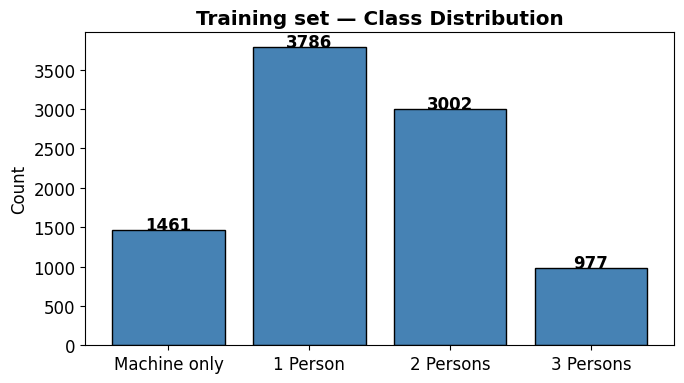

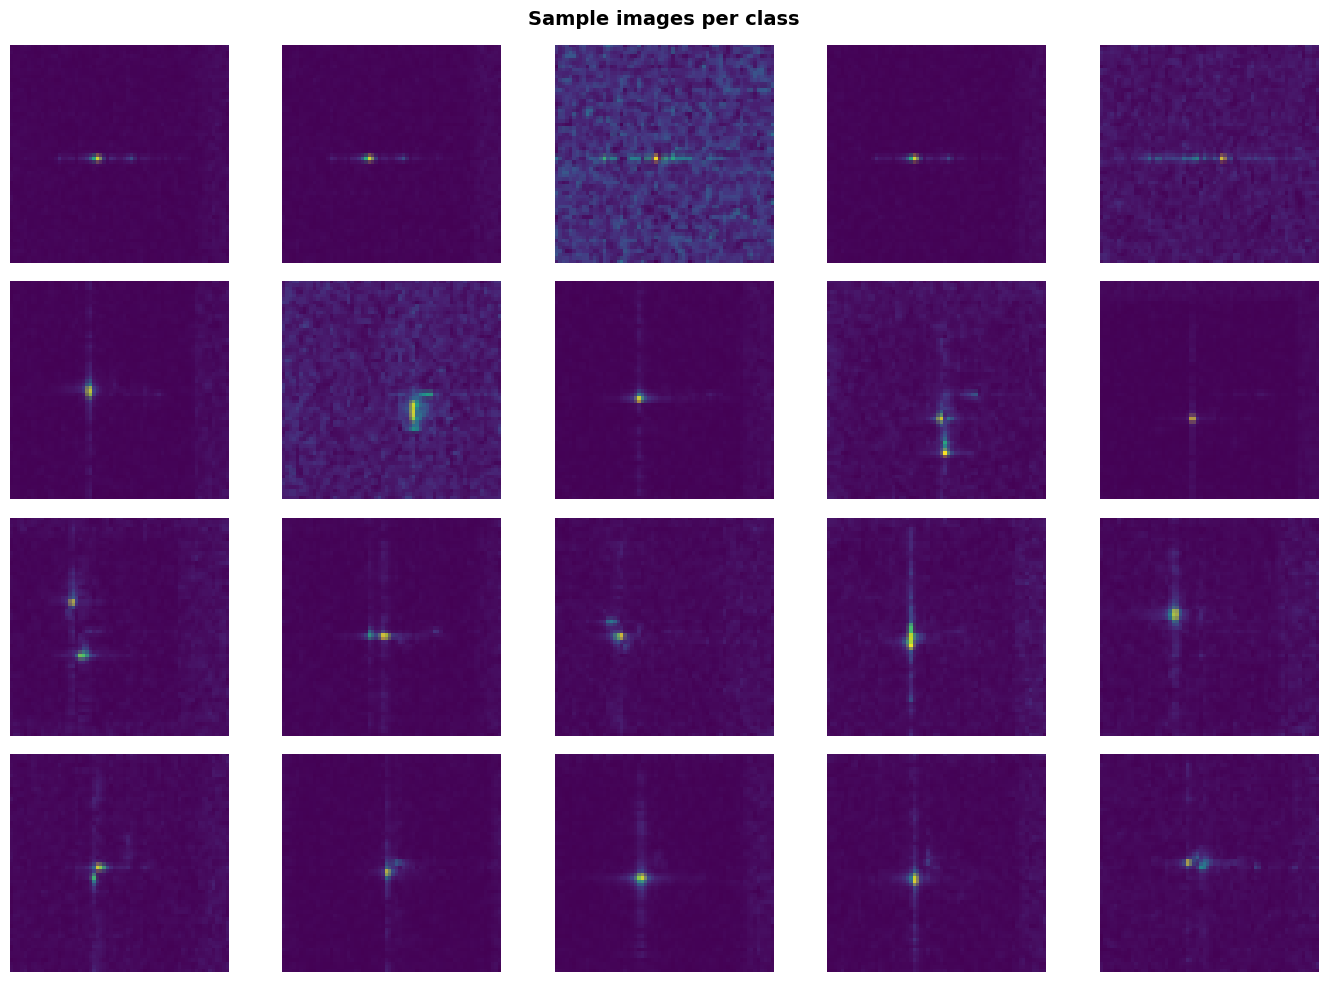

In [ ]:
# Class distribution
counts = np.bincount(y_train_all)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='black')
ax.set_title("Training set — Class Distribution", fontweight='bold')
ax.set_ylabel("Count")
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 5 sample images per class
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(14, 10))
fig.suptitle("Sample images per class", fontsize=14, fontweight='bold')
for cls in range(NUM_CLASSES):
    idx = np.where(y_train_all == cls)[0][:5]
    for j, i in enumerate(idx):
        axes[cls, j].imshow(X_train_all[i])
        axes[cls, j].axis('off')
        if j == 0:
            axes[cls, j].set_ylabel(CLASS_NAMES[cls], fontsize=10, rotation=90, labelpad=40)
plt.tight_layout()
plt.show()

## 4. Train / Validation Split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all,
    test_size=VAL_SPLIT,
    random_state=42,
    stratify=y_train_all
)

y_train_enc = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_enc   = keras.utils.to_categorical(y_val,   NUM_CLASSES)

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}")
print(f"Train class counts: {np.bincount(y_train)}")
print(f"Val   class counts: {np.bincount(y_val)}")

Train : (7842, 64, 64, 3)  |  Val : (1384, 64, 64, 3)
Train class counts: [1242 3218 2552  830]
Val   class counts: [219 568 450 147]


## 5. Data Augmentation & tf.data Pipeline

In [ ]:
@tf.function
def augment(image, label):
    image = tf.image.random_flip_left_right(image)

    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train_enc))
    .shuffle(len(X_train), seed=42)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .repeat()           # prevents 'ran out of data' error
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val_enc))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

steps_per_epoch  = len(X_train) // BATCH_SIZE
validation_steps = len(X_val)   // BATCH_SIZE
print(f"steps_per_epoch: {steps_per_epoch}  |  validation_steps: {validation_steps}")

steps_per_epoch: 245  |  validation_steps: 43


## 6. Model Architecture

A lightweight CNN with two convolutional blocks and dropout regularisation.
The output layer uses softmax for 4-class classification.

In [ ]:
def build_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), num_classes=NUM_CLASSES):
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.25),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.25),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.25),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Dropout(0.25),

        GlobalAveragePooling2D(),  # better than Flatten for generalization
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ], name="Custom_CNN_v2")
    return model

model_cnn = build_cnn()
model_cnn.summary()

Model: "Custom_CNN_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,030,532 (3.93 MB)

 Trainable params: 1,029,124 (3.93 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 7. Class Weights

In [ ]:
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", {CLASS_NAMES[k]: round(v, 3) for k, v in class_weight_dict.items()})

Class weights: {'Machine only': np.float64(1.579), '1 Person': np.float64(0.609), '2 Persons': np.float64(0.768), '3 Persons': np.float64(2.362)}


## 8. Training

In [ ]:
model_cnn.compile(
    loss=keras.losses.CategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

callbacks_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

history_cnn = model_cnn.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_ds,
    validation_steps=validation_steps,
    callbacks=callbacks_cnn,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.5152 - loss: 1.0737 - val_accuracy: 0.3263 - val_loss: 8.2519 - learning_rate: 0.0010
Epoch 2/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6809 - loss: 0.7206 - val_accuracy: 0.4310 - val_loss: 7.1991 - learning_rate: 0.0010
Epoch 3/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7508 - loss: 0.5944 - val_accuracy: 0.7892 - val_loss: 0.5011 - learning_rate: 0.0010
Epoch 4/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8020 - loss: 0.4956 - val_accuracy: 0.7733 - val_loss: 0.4989 - learning_rate: 0.0010
Epoch 5/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8223 - loss: 0.4415 - val_accuracy: 0.8539 - val_loss: 0.3639 - learning_rate: 0.0010
Epoch 6/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8439 - loss: 0.3927 - val_accuracy: 0.8103 - val_loss: 0.4447 - learning_rate: 0.0010
Epoch 7/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8567 - 

## 9. Training Curves

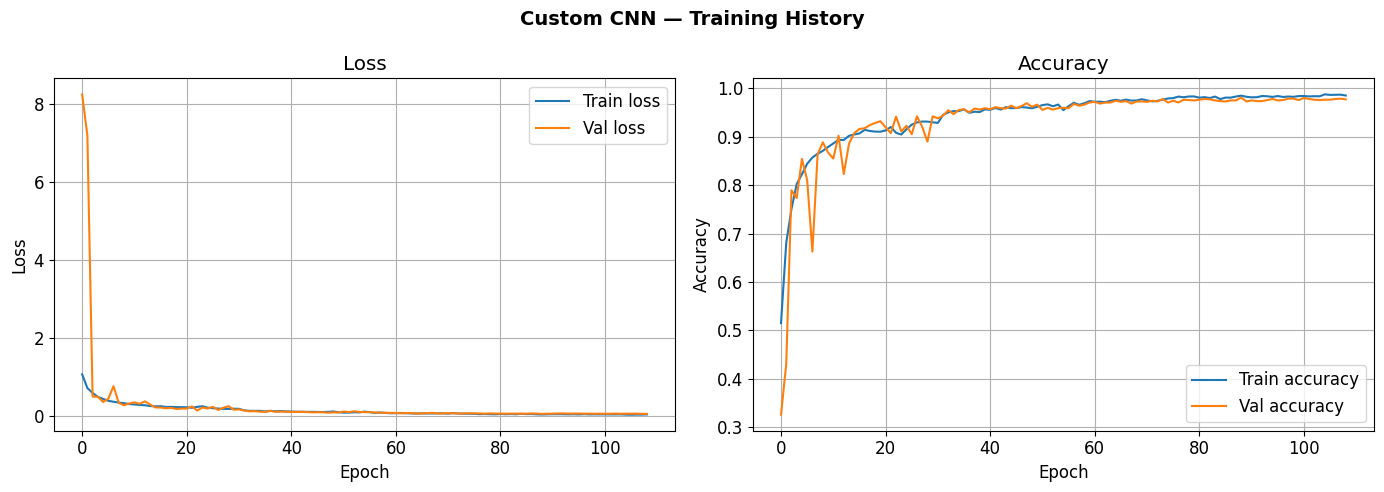

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Custom CNN — Training History", fontsize=14, fontweight='bold')

axes[0].plot(history_cnn.history['loss'],     label='Train loss')
axes[0].plot(history_cnn.history['val_loss'], label='Val loss')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_cnn.history['accuracy'],     label='Train accuracy')
axes[1].plot(history_cnn.history['val_accuracy'], label='Val accuracy')
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 10. Evaluation on Validation Set

Accuracy         : 0.9805
Macro F1-score   : 0.9794
Weighted F1-score: 0.9804

              precision    recall  f1-score   support

Machine only       1.00      1.00      1.00       219
    1 Person       0.98      0.99      0.98       568
   2 Persons       0.98      0.97      0.98       450
   3 Persons       0.99      0.94      0.96       147

    accuracy                           0.98      1384
   macro avg       0.98      0.98      0.98      1384
weighted avg       0.98      0.98      0.98      1384



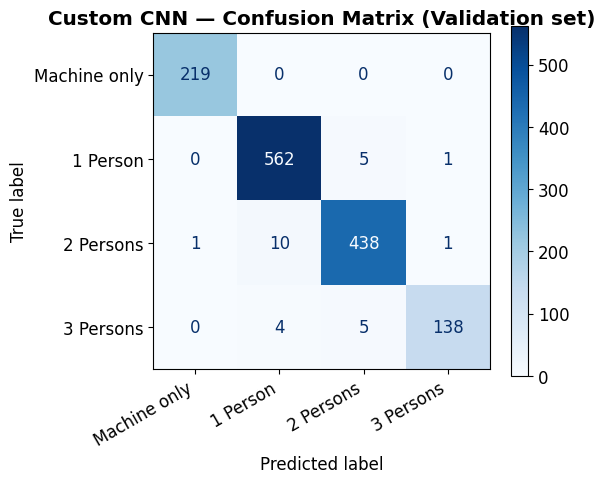

In [ ]:
y_pred_proba = model_cnn.predict(X_val, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

acc = np.mean(y_pred == y_val)
f1  = f1_score(y_val, y_pred, average='macro')
f1w = f1_score(y_val, y_pred, average='weighted')

print(f"Accuracy         : {acc:.4f}")
print(f"Macro F1-score   : {f1:.4f}")
print(f"Weighted F1-score: {f1w:.4f}")
print()
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Custom CNN — Confusion Matrix (Validation set)", fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 11. Error Analysis — Misclassified Samples

Misclassified: 27 / 1384


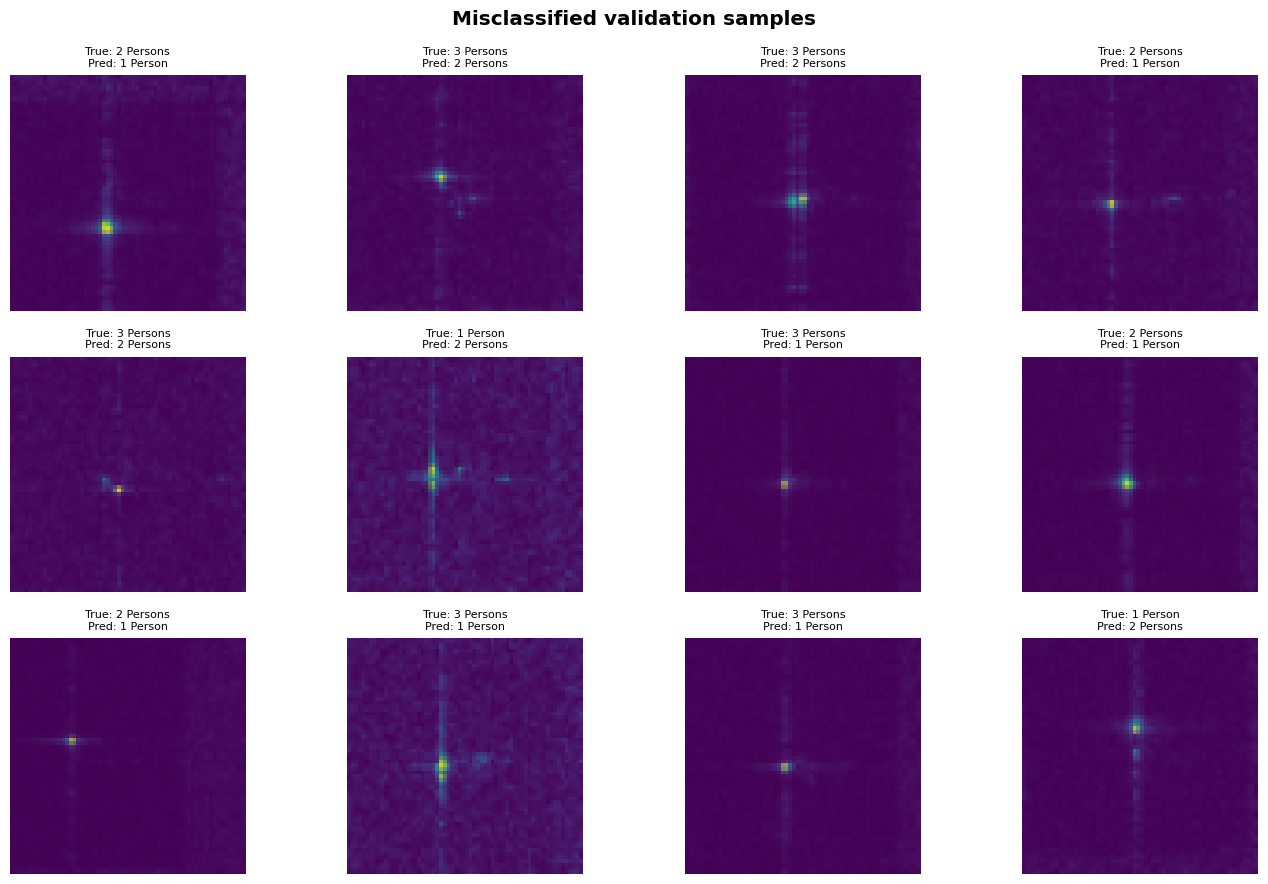

In [ ]:
wrong_idx = np.where(y_pred != y_val)[0]
print(f"Misclassified: {len(wrong_idx)} / {len(y_val)}")

show = wrong_idx[:12]
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle("Misclassified validation samples", fontweight='bold')
for ax, idx in zip(axes.flat, show):
    ax.imshow(X_val[idx])
    ax.set_title(
        f"True: {CLASS_NAMES[y_val[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}",
        fontsize=8
    )
    ax.axis('off')
plt.tight_layout()
plt.show()

## 12. Kaggle Submission

In [ ]:
y_test_pred = np.argmax(model_cnn.predict(X_test, verbose=0), axis=1)

submission = pd.DataFrame({
    'id'    : test_ids,
    'target': y_test_pred
})

submission.to_csv("submission.csv", index=False)
print("Saved to submission.csv")
print(submission.head(10))
print(f"\nPredicted class distribution:\n{pd.Series(y_test_pred).value_counts().sort_index()}")

Saved to submission.csv
     id  target
0  9227       2
1  9228       2
2  9229       0
3  9230       0
4  9231       1
5  9232       1
6  9233       1
7  9234       1
8  9235       1
9  9236       2

Predicted class distribution:
0     599
1    1648
2    1302
3     406
Name: count, dtype: int64
